### Random Forest base. (adaptado a variables categóricas)

A diferencia de CatBoost o LightGBM, que saben manejar categorías de forma nativa (y brillante), el RandomForestClassifier de Scikit-Learn solo acepta números.

Si le pasamos los números de las categorías tal cual (Label Encoding), el Random Forest va a creer que hay una relación matemática (ej. creerá que el "Color 3" es mayor que el "Color 1"), lo cual arruina el modelo. Y si hacemos One-Hot Encoding (crear una columna por cada categoría) para variables de alta cardinalidad como las Razas (Breed1 y Breed2), crearemos cientos de columnas. Esto genera una matriz tan dispersa que el Random Forest pierde fuerza y no logra elegir buenos cortes.

Para mantenerlo como un modelo base simple (sin complicarnos con Target Encoding), aplicaremos esta estrategia:

One-Hot Encoding (OHE): Para variables nominales de baja cardinalidad (Colores, Género, Estado, Salud).

Frequency Encoding: Para las variables de alta cardinalidad (Breed1 y Breed2). En lugar de crear 300 columnas de razas, reemplazamos el código de la raza por la cantidad de veces que aparece en el dataset. Esto le da una señal numérica excelente al árbol: le permite distinguir entre razas extremadamente comunes (ej. mestizos) y razas exóticas o raras, usando una sola columna.


1_Carga del dataset train

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import cohen_kappa_score

# 1. Cargar los datos
df = pd.read_csv('C:/Users/GWF/Documents/GitHub/UA_MDM_Labo2/input/petfinder-adoption-prediction/train/train.csv')
# Mostrar el dataset
df.head()

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,...,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,...,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,...,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,...,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


Eliminación de variables y tratamiento de variables categóricas para adaptarlas al Random Forest

In [6]:
# 2. Eliminar variables de identidad y texto libre (Leakage y ruido)
columnas_a_eliminar = ['PetID', 'RescuerID', 'Name', 'Description']
df = df.drop(columns=columnas_a_eliminar)

# 3. TRATAMIENTO DE VARIABLES CATEGÓRICAS

# A) Frequency Encoding para Alta Cardinalidad (Razas)
# Calculamos la frecuencia de cada raza y reemplazamos el ID por ese número.
for col in ['Breed1', 'Breed2']:
    frecuencias = df[col].value_counts().to_dict()
    df[col + '_freq'] = df[col].map(frecuencias)

# Eliminamos las columnas originales de raza que ya no nos sirven numéricamente
df = df.drop(columns=['Breed1', 'Breed2'])

# B) One-Hot Encoding para Baja Cardinalidad (Nominales)
# Variables que no tienen un orden matemático pero tienen pocas categorías
columnas_nominales = ['Type', 'Gender', 'Color1', 'Color2', 'Color3', 'State']
df = pd.get_dummies(df, columns=columnas_nominales, drop_first=True)

# Nota: Variables como 'Vaccinated', 'Health', 'MaturitySize' son ordinales 
# (tienen un orden lógico como "Sano, Herido leve, Herido grave"). 
# Las dejamos tal cual están (1, 2, 3) porque el árbol entiende bien ese orden.
df.head()

,Age,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,VideoAmt,...,State_41330,State_41332,State_41335,State_41336,State_41342,State_41345,State_41361,State_41367,State_41401,State_41415
0,3,1,1,2,2,2,1,1,100,0,...,False,False,False,False,False,False,False,False,False,False
1,1,2,2,3,3,3,1,1,0,0,...,False,False,False,False,False,False,False,False,True,False
2,1,2,2,1,1,2,1,1,0,0,...,False,False,False,False,False,False,False,False,False,False
3,4,2,1,1,1,2,1,1,150,0,...,False,False,False,False,False,False,False,False,True,False
4,1,2,1,2,2,2,1,1,0,0,...,False,False,False,False,False,False,False,False,False,False


Separar en train y test de manera estratificada.

In [ ]:
# 4. Definir Target (y) y Features (X)
y = df['AdoptionSpeed']
X = df.drop(columns=['AdoptionSpeed'])

# 5. Separar en train y test (66% / 34%). Es importante estratificar para mantener la proporción de clases.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.34, 
    random_state=42, 
    stratify=y
)
print(f"Datos cargados: {X_train.shape[0]} filas para entrenar y {X_test.shape[0]} para test.")

Datos cargados: 9895 filas para entrenar y 5098 para test.


#### Entrenamiento y test del modelo

In [8]:
# 6. Configurar el modelo y la validación cruzada
# Usamos max_depth para ayudar a controlar un poco más el overfitting
rf = RandomForestClassifier(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 7. Entrenamiento y evaluación CV (Stratified K-Fold + QWK)
kappa_scores = []

for train_idx, val_idx in skf.split(X_train, y_train):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    rf.fit(X_fold_train, y_fold_train)
    preds = rf.predict(X_fold_val)
    
    kappa = cohen_kappa_score(y_fold_val, preds, weights='quadratic')
    kappa_scores.append(kappa)

print(f"Quadratic Weighted Kappa en CV (Media): {np.mean(kappa_scores):.4f}")

# 8. Evaluación final en Test
rf.fit(X_train, y_train)
test_preds = rf.predict(X_test)
test_kappa = cohen_kappa_score(y_test, test_preds, weights='quadratic')

print(f"Quadratic Weighted Kappa en Test: {test_kappa:.4f}")


Quadratic Weighted Kappa en CV (Media): 0.3455
Quadratic Weighted Kappa en Test: 0.3295


#### Importancia de variables

C:\Users\GWF\AppData\Local\Temp\ipykernel_3228\517827472.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


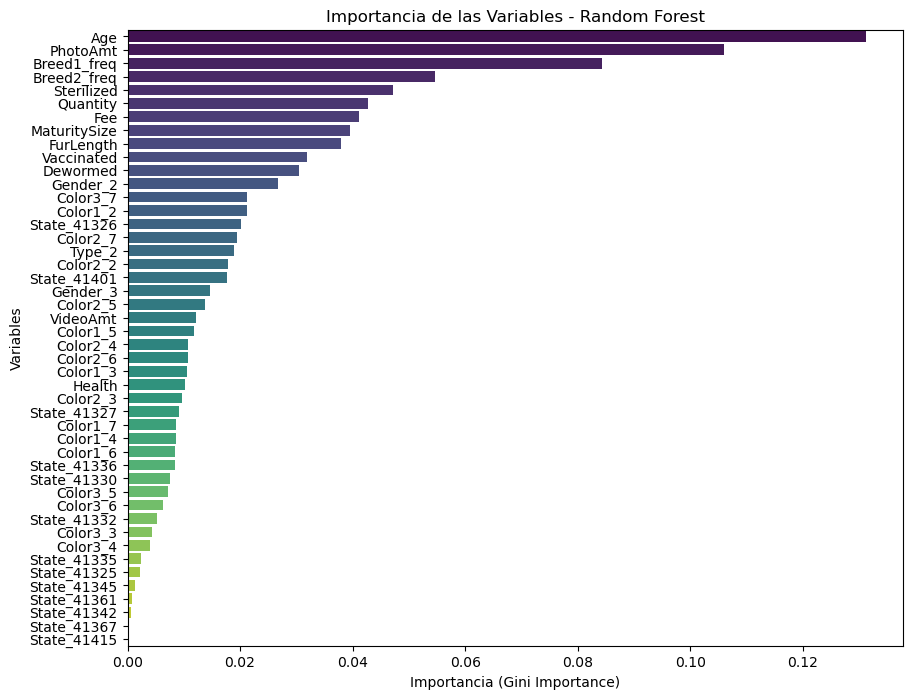

Top 5 variables más influyentes:
        Feature  Importance
0           Age    0.131143
10     PhotoAmt    0.106042
11  Breed1_freq    0.084240
12  Breed2_freq    0.054702
5    Sterilized    0.047167


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Obtener la importancia de las variables del modelo final
importances = rf.feature_importances_
feature_names = X_train.columns

# 2. Crear un DataFrame para facilitar el gráfico
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Graficar
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Importancia de las Variables - Random Forest')
plt.xlabel('Importancia (Gini Importance)')
plt.ylabel('Variables')
plt.show()

# 4. Mostrar las top 5 para análisis rápido
print("Top 5 variables más influyentes:")
print(feature_importance_df.head(5))